In [1]:
import numpy as np
import pandas as pd


In [2]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='cp1252')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
#Data Cleaning
#EDA
#Text Preprocessing
#Model building
#Evalution
#Improvement
#website
#deploy

## 1.Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample()

,v1,v2
1681,ham,Y lei?


In [9]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
312,ham,He says he'll give me a call when his friend's...
2292,ham,:-( that's not v romantic!
3531,ham,"Actually, my mobile is full of msg. And i m do..."
2889,ham,Shuhui has bought ron's present it's a swatch ...
4688,ham,"Didn't try, g and I decided not to head out"


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [11]:
df['target']=encoder.fit_transform(df['target'])

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df=df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

## 2.EDA

In [18]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

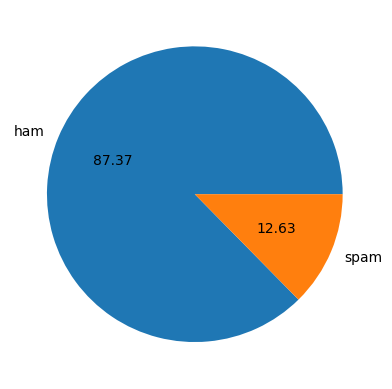

In [20]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [21]:
#Data is Imbalanced

In [22]:
import nltk

In [23]:
!pip install nltk

In [24]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tumpa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
df.loc[:, 'num_characters'] = df['text'].apply(len)

In [26]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
df.loc[:, 'num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [28]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [29]:
df.loc[:, 'num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [30]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [31]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [32]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [34]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

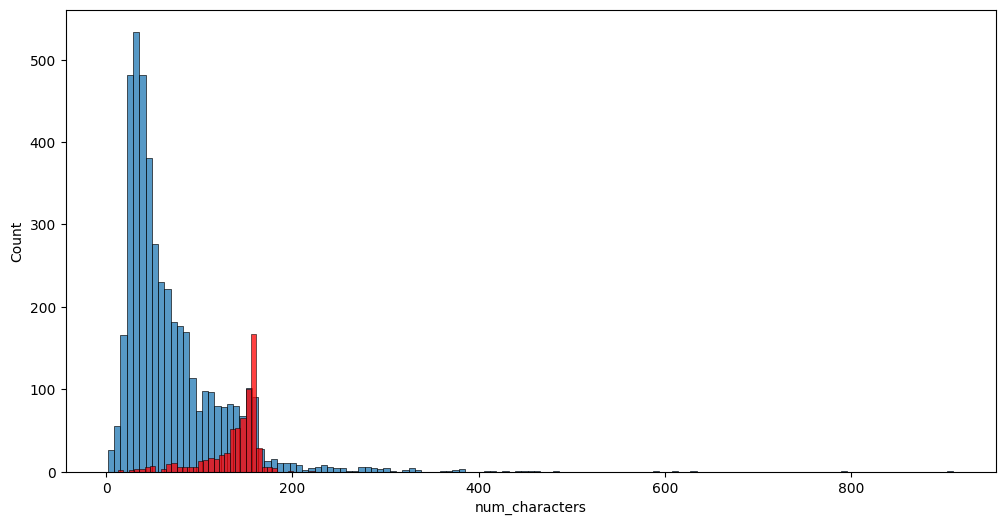

In [35]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

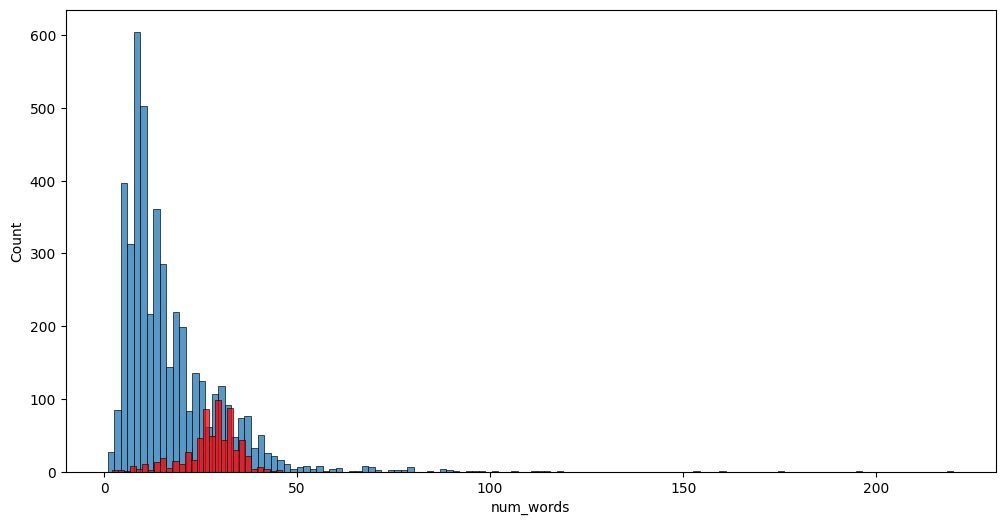

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

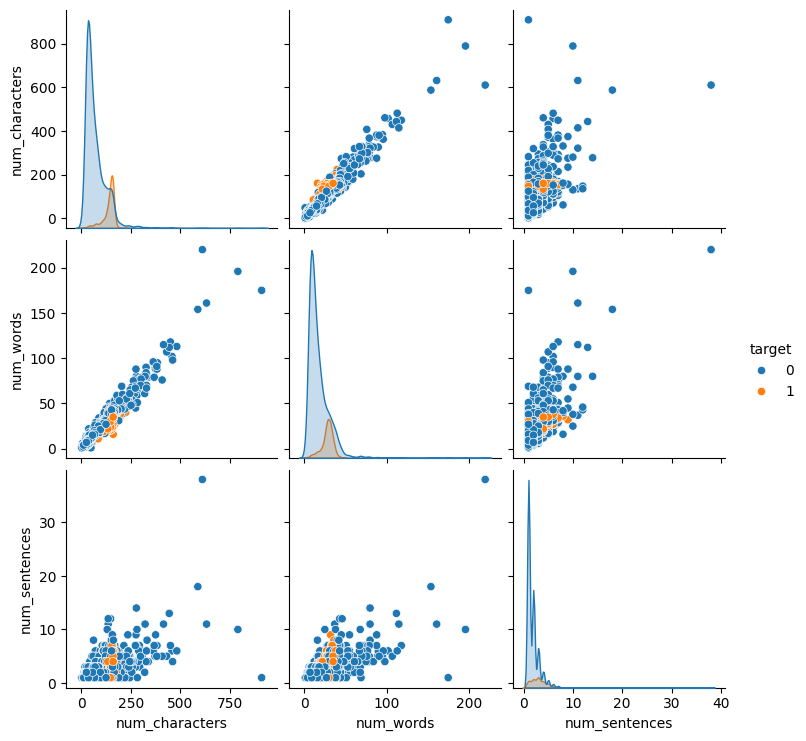

In [37]:
sns.pairplot(df,hue='target')

<Axes: >

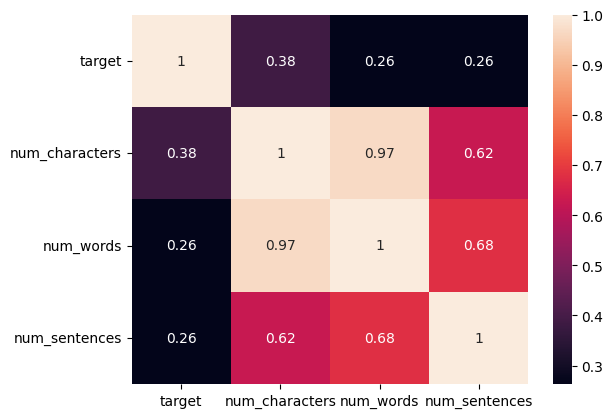

In [38]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

## 3.Data Preprocessing
  .Lowercase
  .Tokenization
  .Removing special characters
 .Removing stop words and punctuation
 .stemming

In [39]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [42]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem("loving")

'love'

In [43]:
import string
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [44]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [45]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [46]:
df.loc[:, 'transformed_text'] = df['text'].apply(transform_text)

In [47]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [48]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [49]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

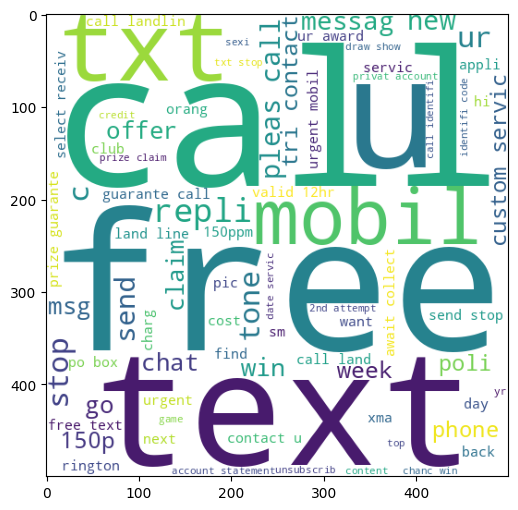

In [50]:
plt.figure(figsize=(10,6))
plt.imshow(spam_wc)

In [51]:
ham_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

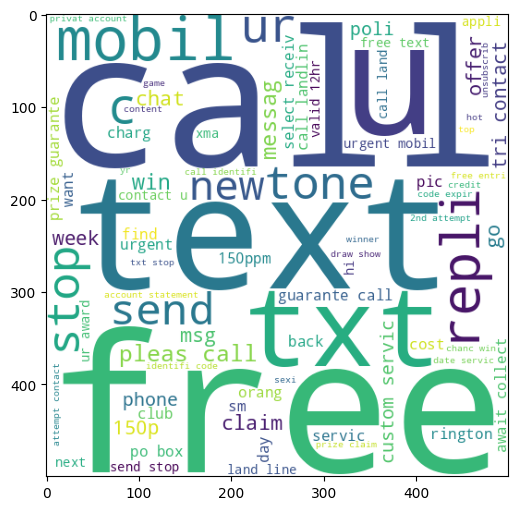

In [52]:
plt.figure(figsize=(10,6))
plt.imshow(ham_wc)

In [53]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [54]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [55]:
len(spam_corpus)

9939

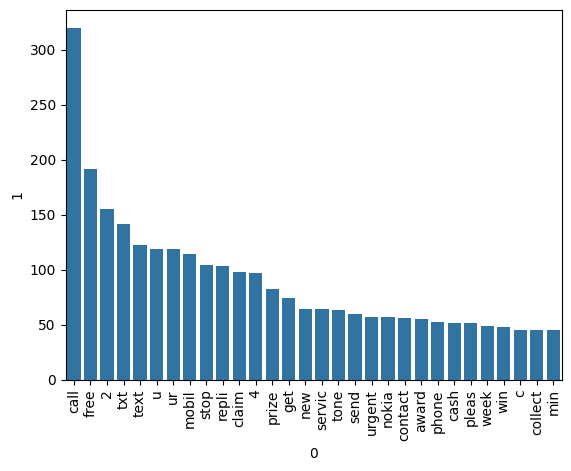

In [56]:
from collections import Counter
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=top_words[0], y=top_words[1])
plt.xticks(rotation='vertical')
plt.show()

In [57]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [58]:
len(ham_corpus)

35404

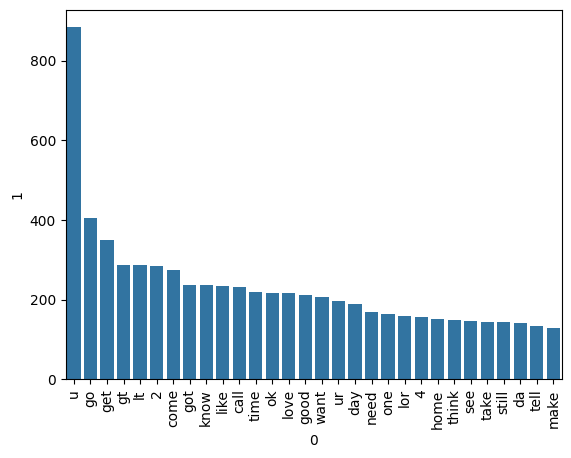

In [59]:
from collections import Counter
top_words = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=top_words[0], y=top_words[1])
plt.xticks(rotation='vertical')
plt.show()

In [60]:
#Text Vectorization
#using BOW
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# 4.Model Building

In [128]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [129]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [130]:
X=np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [131]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [132]:
X.shape

(5169, 3001)

In [133]:
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.12004405],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.02973568],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.1685022 ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.06057269],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.13546256],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.02643172]], shape=(5169, 3001))

In [134]:
y=df['target'].values

In [135]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [136]:
from sklearn.model_selection import train_test_split

In [137]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [138]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score

In [139]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [140]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[784 112]
 [ 16 122]]
0.5213675213675214


In [141]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9787234042553191
[[889   7]
 [ 15 123]]
0.9461538461538461


In [142]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [143]:
#tfidf -> MNB
!pip install xgboost

In [144]:
# Linear models
from sklearn.linear_model import LogisticRegression

# Support Vector Machines
from sklearn.svm import SVC

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Decision Trees
from sklearn.tree import DecisionTreeClassifier

# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Ensemble methods
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)

# XGBoost
from xgboost import XGBClassifier

In [145]:
# Probabilistic models
nb_multinomial = MultinomialNB()

# Linear models
log_reg = LogisticRegression(solver='liblinear',penalty='l1')

# Support Vector Machines
svc= SVC(kernel='sigmoid', gamma=1.0)

# Tree-based models
decision_tree = DecisionTreeClassifier(max_depth=5)
random_forest = RandomForestClassifier(n_estimators=50, random_state=2)
extra_trees = ExtraTreesClassifier(n_estimators=50, random_state=2)
grad_boost = GradientBoostingClassifier(n_estimators=50, random_state=2)


# Ensemble models
adaboost = AdaBoostClassifier(n_estimators=50, random_state=42)
bagging = BaggingClassifier(n_estimators=50, random_state=42)

# K-Nearest Neighbors
knn = KNeighborsClassifier()

# XGBoost (optional, requires xgboost installed)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)


In [146]:
clfs = {
    # Probabilistic models
    'MultinomialNB': nb_multinomial,
    
    # Linear models
    'LogisticRegression': log_reg,
    
    # Support Vector Machines
    'SVC': svc,
    
    # Tree-based models
    'DecisionTree': decision_tree,
    'RandomForest': random_forest,
    'ExtraTrees': extra_trees,
    'GradientBoosting': grad_boost,
    
    # Ensemble models
    'AdaBoost': adaboost,
    'Bagging': bagging,
    
    # K-Nearest Neighbors
    'KNN': knn,
    
    # XGBoost (optional)
    'XGBoost': xgb  # will be None if xgboost is not installed
}

In [147]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    return accuracy,precision

In [148]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9729206963249516, 0.9435483870967742)

In [149]:
# Lists to store metrics
accuracy_list = []
precision_list = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    # Print results
    print(f"\nFor {name}:")
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    
    # Append to lists
    accuracy_list.append(current_accuracy)
    precision_list.append(current_precision)


For MultinomialNB:
Accuracy: 0.9787234042553191
Precision: 0.9461538461538461

For LogisticRegression:
Accuracy: 0.9680851063829787
Precision: 0.9646017699115044

For SVC:
Accuracy: 0.9729206963249516
Precision: 0.9435483870967742

For DecisionTree:
Accuracy: 0.9487427466150871
Precision: 0.897196261682243

For RandomForest:
Accuracy: 0.9729206963249516
Precision: 0.9824561403508771

For ExtraTrees:
Accuracy: 0.9806576402321083
Precision: 0.9836065573770492

For GradientBoosting:
Accuracy: 0.9506769825918762
Precision: 0.9306930693069307

For AdaBoost:
Accuracy: 0.9448742746615088
Precision: 0.8932038834951457

For Bagging:
Accuracy: 0.960348162475822
Precision: 0.8439716312056738

For KNN:
Accuracy: 0.9168278529980658
Precision: 0.9814814814814815


C:\Users\tumpa\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:47:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



For XGBoost:
Accuracy: 0.971953578336557
Precision: 0.9504132231404959


In [150]:
performance_df= pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_list,
    'Precision': precision_list
})

# Sort by Accuracy first, then Precision (both descending)
performance_df = performance_df.sort_values(
    by=['Precision'],
    ascending=False
)



In [151]:
performance_df

,Algorithm,Accuracy,Precision
5,ExtraTrees,0.980658,0.983607
4,RandomForest,0.972921,0.982456
9,KNN,0.916828,0.981481
1,LogisticRegression,0.968085,0.964602
10,XGBoost,0.971954,0.950413
0,MultinomialNB,0.978723,0.946154
2,SVC,0.972921,0.943548
6,GradientBoosting,0.950677,0.930693
3,DecisionTree,0.948743,0.897196
7,AdaBoost,0.944874,0.893204


In [152]:
performance_df1=pd.melt(performance_df,id_vars='Algorithm')

In [153]:
performance_df1

,Algorithm,variable,value
0,ExtraTrees,Accuracy,0.980658
1,RandomForest,Accuracy,0.972921
2,KNN,Accuracy,0.916828
3,LogisticRegression,Accuracy,0.968085
4,XGBoost,Accuracy,0.971954
5,MultinomialNB,Accuracy,0.978723
6,SVC,Accuracy,0.972921
7,GradientBoosting,Accuracy,0.950677
8,DecisionTree,Accuracy,0.948743
9,AdaBoost,Accuracy,0.944874


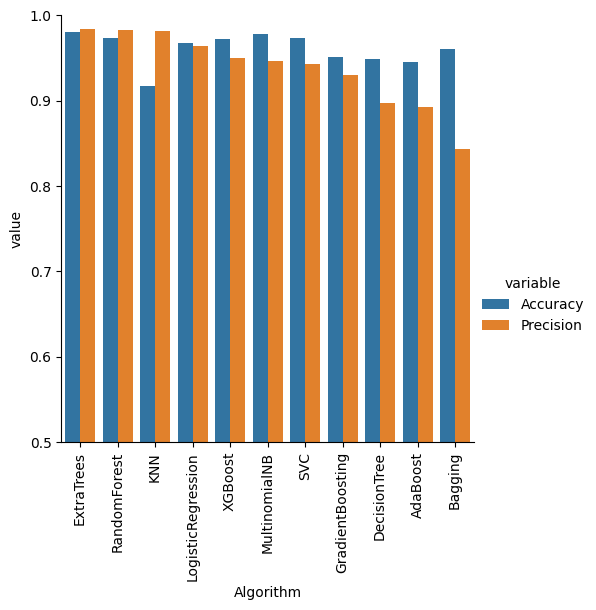

In [154]:
sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [155]:
#model improve
#1.Change the max_features

In [163]:
#Voting Classifier
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
rf = RandomForestClassifier(n_estimators=50, random_state=2)
nb = MultinomialNB()
from sklearn.ensemble import VotingClassifier

In [164]:
voting=VotingClassifier(estimators=[('et',etc),('rf',rf),('nb',nb)],voting='soft')

In [165]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2)),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2)),
                             ('nb', MultinomialNB())],
                 voting='soft')

In [167]:
y_pred=voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9845261121856866
Precision 0.9919354838709677


In [168]:
#Stacking
estimators=[('et',etc),('rf',rf),('nb',nb)]
final_estimator=RandomForestClassifier()

In [170]:
from sklearn.ensemble import StackingClassifier

In [174]:
clf= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [176]:
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.97678916827853
Precision 0.9318181818181818


In [177]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [178]:
pwd

'C:\\Users\\tumpa\\SMS spam Classification'